In [10]:
import os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from ipywidgets import interact_manual, widgets

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# ==========================================
# DATAFILE CHECK & LOAD
# ==========================================

csv_filename = 'Car details updated.csv'

if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"Error: '{csv_filename}' not found.")

print("Initializing Data Pipeline for Car details updated.csv...")
df = pd.read_csv(csv_filename).dropna()

Initializing Data Pipeline for Car details updated.csv...


In [12]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

df['Brand'] = df['name'].apply(lambda x: x.split()[0])
df['engine_cc'] = df['engine'].str.replace(' CC', '', regex=False).astype(float)
df['max_power_bhp'] = pd.to_numeric(df['max_power'].str.replace(' bhp', '', regex=False), errors='coerce')
df = df.dropna()

In [13]:
# ==========================================
# ENCODERS & FEATURE ASSEMBLY
# ==========================================

le_dict = {
    'brand': LabelEncoder().fit(df['Brand']),
    'fuel': LabelEncoder().fit(df['fuel']),
    'seller': LabelEncoder().fit(df['seller_type']),
    'trans': LabelEncoder().fit(df['transmission'])
}

df['brand_enc'] = le_dict['brand'].transform(df['Brand'])
df['fuel_enc'] = le_dict['fuel'].transform(df['fuel'])
df['seller_enc'] = le_dict['seller'].transform(df['seller_type'])
df['trans_enc'] = le_dict['trans'].transform(df['transmission'])

X = df[['year', 'km_driven', 'engine_cc', 'max_power_bhp', 'brand_enc', 'fuel_enc', 'seller_enc', 'trans_enc']]
y = df['selling_price']

In [14]:
# ==========================================
# TRAIN/TEST SPLIT & MODEL TRAINING
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Advanced Gradient Boosting Model...")
gb_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
print(f"\n--- MODEL METRICS ---\nR2 Score: {r2_score(y_test, y_pred):.4f}\nMAE: ₹{mean_absolute_error(y_test, y_pred):,.2f}\n")

Training Advanced Gradient Boosting Model...



--- MODEL METRICS ---
R2 Score: 0.9831
MAE: ₹67,231.44



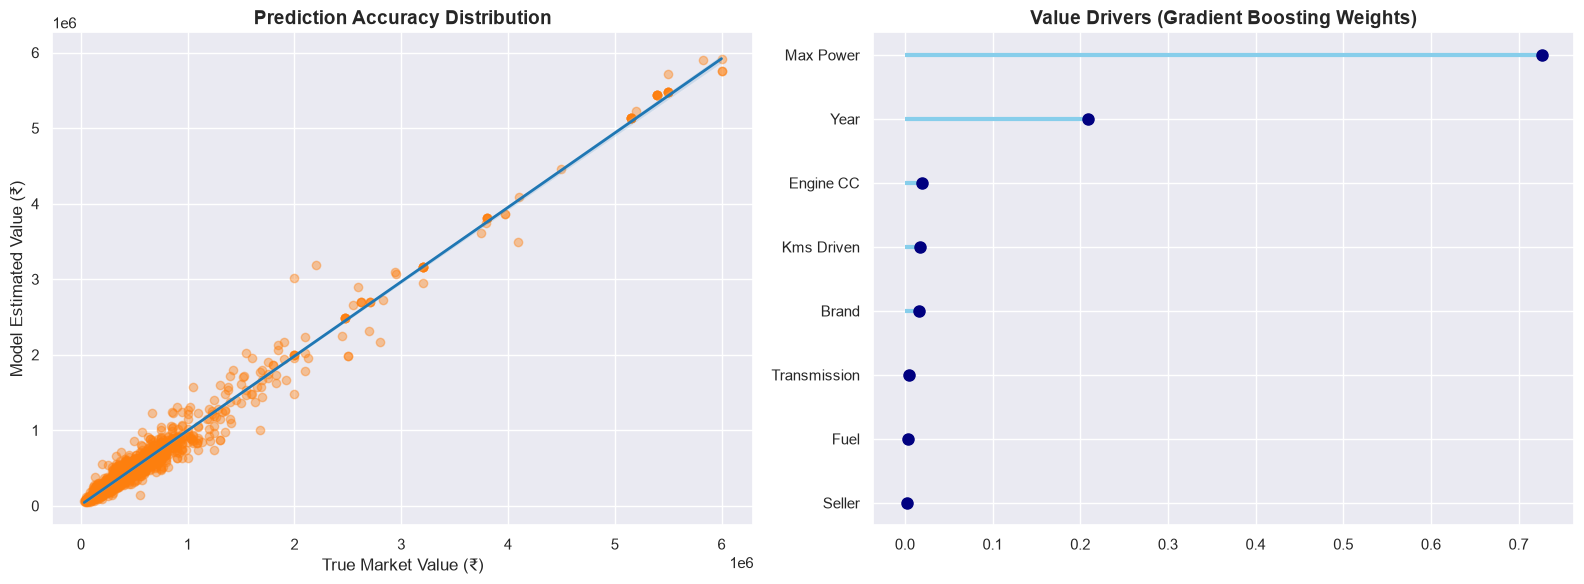

In [15]:
# ==========================================
# EVALUATION & VISUALIZATIONS
# ==========================================

sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(16, 6))

# Chart 1: Prediction Accuracy
ax1 = plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4, 'color':'#ff7f0e'}, line_kws={'color':'#1f77b4', 'lw':2}, ax=ax1)
ax1.set_title('Prediction Accuracy Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('True Market Value (₹)')
ax1.set_ylabel('Model Estimated Value (₹)')

# Chart 2: Lollipop Feature Importance
ax2 = plt.subplot(1, 2, 2)
importances = gb_model.feature_importances_
features = ['Year', 'Kms Driven', 'Engine CC', 'Max Power', 'Brand', 'Fuel', 'Seller', 'Transmission']
feat_df = pd.DataFrame({'Feature': features, 'Value': importances}).sort_values('Value', ascending=True)
ax2.hlines(y=feat_df['Feature'], xmin=0, xmax=feat_df['Value'], color='skyblue', linewidth=3)
ax2.plot(feat_df['Value'], feat_df['Feature'], "o", markersize=8, color='navy')
ax2.set_title('Value Drivers (Gradient Boosting Weights)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# INTERACTIVE PREDICTION UI
# ==========================================

print("\n🚗 Test the Gradient Boosting Model 🚗")
@interact_manual(
    Brand=widgets.Dropdown(options=le_dict['brand'].classes_, value=le_dict['brand'].classes_[0]),
    Year=widgets.IntSlider(min=df['year'].min(), max=df['year'].max(), value=2018),
    Kms_Driven=widgets.IntText(value=30000),
    Engine_CC=widgets.IntText(value=1197),
    Power_BHP=widgets.IntText(value=83),
    Fuel=widgets.Dropdown(options=le_dict['fuel'].classes_, value=le_dict['fuel'].classes_[0]),
    Seller=widgets.Dropdown(options=le_dict['seller'].classes_, value=le_dict['seller'].classes_[0]),
    Transmission=widgets.Dropdown(options=le_dict['trans'].classes_, value=le_dict['trans'].classes_[0])
)
def predict_car(Brand, Year, Kms_Driven, Engine_CC, Power_BHP, Fuel, Seller, Transmission):
    try:
        feats = [[Year, Kms_Driven, Engine_CC, Power_BHP,
                  le_dict['brand'].transform([Brand])[0], le_dict['fuel'].transform([Fuel])[0],
                  le_dict['seller'].transform([Seller])[0], le_dict['trans'].transform([Transmission])[0]]]
        print(f"\n>> 💰 Estimated Value: ₹ {gb_model.predict(feats)[0]:,.2f}")
    except Exception as e:
        print(f"Error: {e}")


🚗 Test the Gradient Boosting Model 🚗


interactive(children=(Dropdown(description='Brand', options=('Ambassador', 'Ashok', 'Audi', 'BMW', 'Chevrolet'…